# 01 OMR Probe: Staff-Line Evidence

This notebook is the first small experiment for the project.

It does **not** try to recognize notes. It asks a narrower question:

```text
Can simple image processing find staff-line evidence in a notated page?
```

The output should be inspected visually. The goal is to learn what kind of positional evidence the image naturally gives us before connecting it to audio.

In [9]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["image.cmap"] = "gray"

## 1. Choose an Input Image

Put a scanned page, screenshot, or crop of sheet music somewhere in the repository and set `IMAGE_PATH` below.

For the first pass, prefer a clean black-and-white or grayscale image with one page or one system. The point is not generality yet; it is to see whether staff-line evidence is easy to extract at all.

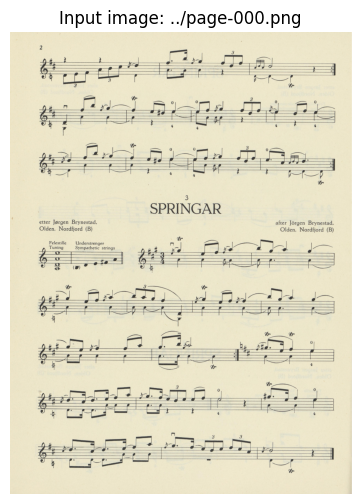

In [10]:
# The notebook lives in notebooks/, so this points to the image in the repo root.
IMAGE_PATH = Path("../page-000.png")

if not IMAGE_PATH.exists():
    raise FileNotFoundError(
        f"Set IMAGE_PATH to a sheet-music image before continuing. Current value: {IMAGE_PATH}"
    )

image_bgr = cv2.imread(str(IMAGE_PATH))
if image_bgr is None:
    raise ValueError(f"OpenCV could not read image: {IMAGE_PATH}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

plt.imshow(image_rgb)
plt.title(f"Input image: {IMAGE_PATH}")
plt.axis("off");

## 2. Binarize the Page

Staff lines are dark horizontal structures. We start by converting the page to a binary image where foreground ink is `1` and background is `0`.

Adaptive thresholding is useful for uneven lighting, but this is only a probe. The visualization is more important than the exact method.

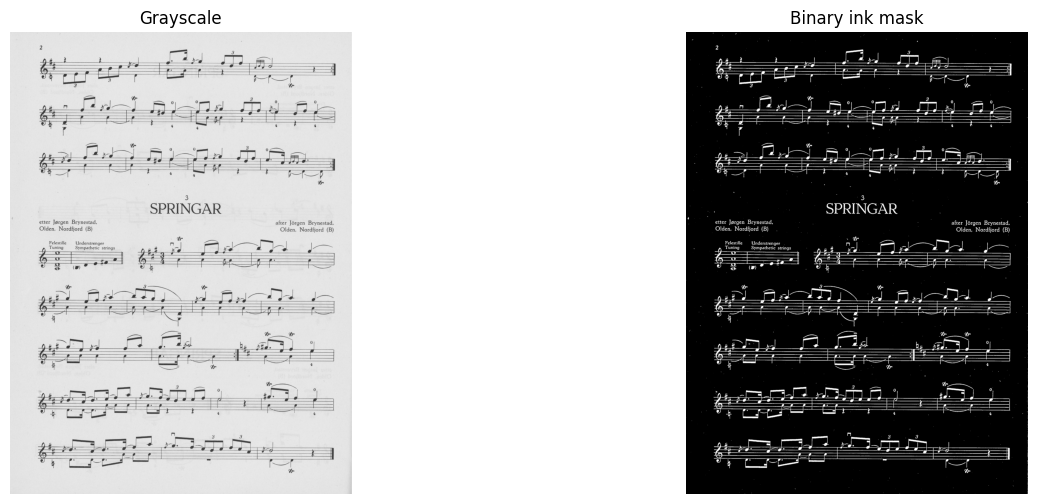

In [11]:
blurred = cv2.GaussianBlur(gray, (3, 3), 0)

binary_inv = cv2.adaptiveThreshold(
    blurred,
    maxValue=255,
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    thresholdType=cv2.THRESH_BINARY_INV,
    blockSize=35,
    C=11,
)

ink = binary_inv > 0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(gray)
axes[0].set_title("Grayscale")
axes[0].axis("off")
axes[1].imshow(ink)
axes[1].set_title("Binary ink mask")
axes[1].axis("off");

## 3. Horizontal Projection Profile

A staff line should create a strong horizontal row signal. Summing ink pixels across each row lowers the image into a one-dimensional positional evidence field over `U_image_y`.

This is the first concrete type-lowering move in the notebook:

```text
binary page -> row evidence bitmap/vector
```

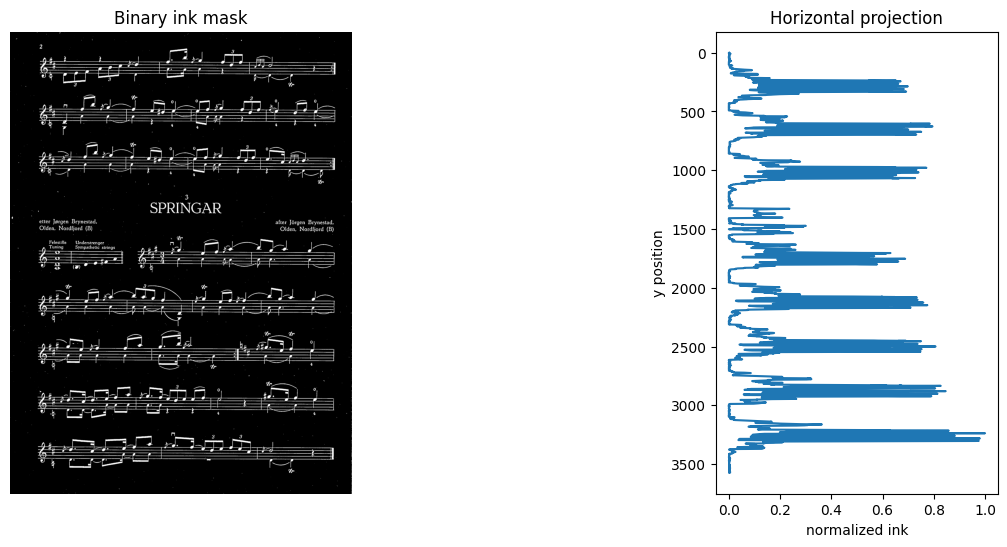

In [12]:
row_ink = ink.sum(axis=1)
row_ink_norm = row_ink / max(row_ink.max(), 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [3, 1]})
axes[0].imshow(ink)
axes[0].set_title("Binary ink mask")
axes[0].axis("off")
axes[1].plot(row_ink_norm, np.arange(len(row_ink_norm)))
axes[1].invert_yaxis()
axes[1].set_title("Horizontal projection")
axes[1].set_xlabel("normalized ink")
axes[1].set_ylabel("y position");

## 4. Candidate Staff Rows

This simple detector looks for rows with unusually high horizontal ink. It is intentionally crude.

The output is not a final OMR result. It is an evidence field: rows that may participate in staff-line structure.

In [13]:
threshold = np.quantile(row_ink_norm, 0.985)
candidate_rows = np.flatnonzero(row_ink_norm >= threshold)

# Merge adjacent candidate rows into bands, since a printed staff line may be several pixels thick.
def merge_adjacent_positions(positions: np.ndarray, max_gap: int = 1) -> list[tuple[int, int]]:
    if len(positions) == 0:
        return []

    bands = []
    start = prev = int(positions[0])
    for value in positions[1:]:
        value = int(value)
        if value - prev <= max_gap:
            prev = value
            continue
        bands.append((start, prev))
        start = prev = value
    bands.append((start, prev))
    return bands

row_bands = merge_adjacent_positions(candidate_rows, max_gap=2)
row_centers = np.array([(start + end) / 2 for start, end in row_bands])

print(f"Projection threshold: {threshold:.3f}")
print(f"Candidate row bands: {len(row_bands)}")
print(row_bands[:30])

Projection threshold: 0.732
Candidate row bands: 25
[(604, 604), (625, 628), (673, 673), (979, 979), (996, 996), (1018, 1018), (2082, 2082), (2102, 2102), (2124, 2126), (2147, 2148), (2454, 2454), (2477, 2477), (2499, 2500), (2522, 2522), (2541, 2543), (2834, 2835), (2855, 2855), (2877, 2879), (2900, 2901), (2922, 2923), (3215, 3216), (3233, 3238), (3256, 3260), (3278, 3281), (3300, 3304)]


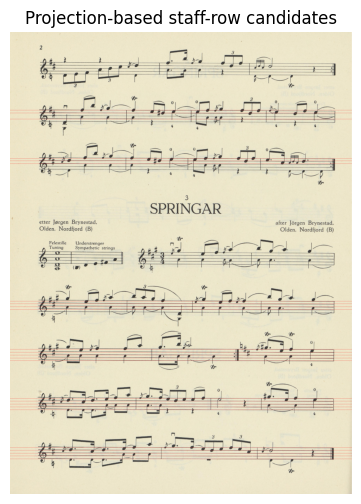

In [14]:
overlay = image_rgb.copy()
for center in row_centers.astype(int):
    cv2.line(overlay, (0, center), (overlay.shape[1] - 1, center), (255, 0, 0), 1)

plt.imshow(overlay)
plt.title("Projection-based staff-row candidates")
plt.axis("off");

## 5. Morphological Horizontal Evidence

Projection profiles can be confused by text, lyrics, beams, or dense notation. A complementary probe is to keep only long horizontal structures with a morphological opening.

This produces another lowered evidence field: pixels likely to belong to long horizontal marks.

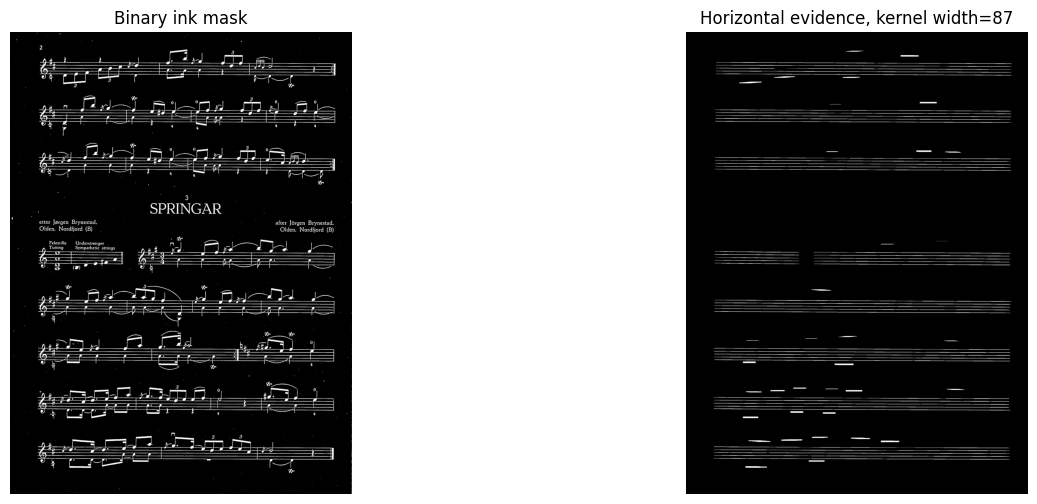

In [15]:
height, width = ink.shape
kernel_width = max(15, width // 30)
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, 1))

horizontal_lines = cv2.morphologyEx(binary_inv, cv2.MORPH_OPEN, horizontal_kernel)
horizontal_evidence = horizontal_lines > 0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(ink)
axes[0].set_title("Binary ink mask")
axes[0].axis("off")
axes[1].imshow(horizontal_evidence)
axes[1].set_title(f"Horizontal evidence, kernel width={kernel_width}")
axes[1].axis("off");

Morphological threshold: 0.499
Morphological row bands: 52
[(237, 238), (242, 243), (259, 259), (264, 264), (284, 287), (303, 303), (306, 310), (325, 325), (330, 332), (603, 604), (607, 607), (625, 630), (647, 654), (670, 676), (692, 698), (978, 979), (994, 997), (1000, 1001), (1017, 1019), (1022, 1024), (1040, 1046), (1063, 1068), (1704, 1704), (1709, 1709), (1728, 1728), (1731, 1731), (1753, 1754), (1777, 1777), (2078, 2083), (2100, 2104)]


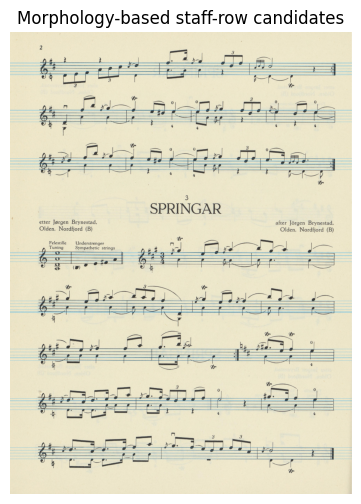

In [16]:
horizontal_row_ink = horizontal_evidence.sum(axis=1)
horizontal_row_norm = horizontal_row_ink / max(horizontal_row_ink.max(), 1)

morph_threshold = np.quantile(horizontal_row_norm, 0.95)
morph_candidate_rows = np.flatnonzero(horizontal_row_norm >= morph_threshold)
morph_bands = merge_adjacent_positions(morph_candidate_rows, max_gap=2)
morph_centers = np.array([(start + end) / 2 for start, end in morph_bands])

print(f"Morphological threshold: {morph_threshold:.3f}")
print(f"Morphological row bands: {len(morph_bands)}")
print(morph_bands[:30])

overlay = image_rgb.copy()
for center in morph_centers.astype(int):
    cv2.line(overlay, (0, center), (overlay.shape[1] - 1, center), (0, 160, 255), 1)

plt.imshow(overlay)
plt.title("Morphology-based staff-row candidates")
plt.axis("off");

## 6. Notes from Inspection

Use this section after running the notebook.

- Did the projection profile produce five-line staff groups?
- Did text, beams, stems, or page borders create false positives?
- Was the morphological kernel too short or too long?
- Does the result look like an evidence field that could help define `U_score`?

A useful next step is not necessarily note recognition. It may be deskewing, staff grouping, or testing several page crops.